# Cross-validation of 2,4-D TKTD model with metamorph data

## Notebook setup

In [1]:
using DrWatson
@quickactivate "."

const SAVETAG_LARVALFIT = "input/Discoglossus_larvae" # directory from which larval/metamorph parameters are loaded
const SAVETAG_JUVENILEFIT = "input/Discoglossus_juveniles" # directory from which juvenile/adult parameters are loaded
const SAVEDIR = "Discoglossus_24D_2025-06-23_numtadpoles" # directory from which TKTD parameters are loaded
const SAVETAG_TKTD = "Discoglossus_24D" 
const SAVETAG = "Discoglossus_24D"

using Revise

includet(scriptsdir("ModelFitting_Discoglossus_24D_UCLM.jl")) 
includet(scriptsdir("CrossValidation_Discoglossus_24D_metamorphs.jl"))

## Generating predictions per PMoA

We had previously selected two plausible PMoAs, $M$ and $A$, and will now generate predictions based on both of them.

### $M$

In [2]:
pmoa_idx = 2
pmoa = PMOAS[pmoa_idx]
f = setup_modelfit(pmoa); # reconstructing ModelFit instance

┌ Info: Overwriting default values of String31["spc.Z", "spc.dI_max_lrv", "spc.k_M_emb", "spc.eta_AS_emb", "spc.H_j1", "spc.gamma", "spc.k_J_emb", "spc.kappa_emb", "spc.watercontent_larvae", "spc.watercontent_juveniles", "spc.time_since_birth"]
└ @ Main c:\Users\simon\Documents\AmphiDEBResearch\WP02_TKTD\scripts\ModelFitting_Discoglossus_24D_UCLM.jl:227
┌ Info: Overwriting default values of String15["spc.dI_max_juv", "spc.eta_AS_juv", "spc.H_p", "spc.k_J_juv", "spc.eta_AR"]
└ @ Main c:\Users\simon\Documents\AmphiDEBResearch\WP02_TKTD\scripts\ModelFitting_Discoglossus_24D_UCLM.jl:236
┌ Info: 
│         Estimating 3 parameters: 
│         ["spc.KD[1,2]", "spc.E[1,2]", "spc.B[1,2]"]
│         
└ @ EcotoxModelFitting C:\Users\simon\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:77
┌ Info: Normalizing data weights
└ @ EcotoxModelFitting C:\Users\simon\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:145
┌ Info: No column `observation_weight` found in data key aquatic. Assu

In [3]:
using ProgressMeter
p_opt = CSV.read(datadir("sims", SAVEDIR, "$(SAVETAG_TKTD)_$(pmoa)", "posterior_summary.csv"), DataFrame).best_fit
sim_opt_M = @showprogress [f.simulator(p_opt) for _ in 1:100];

Progress: 100%|█████████████████████████████████████████| Time: 0:01:35


In [4]:
quant_eval_M = quant_eval_metamorphs(f, sim_opt_M)

Row,endpoint,mre,mre_sd,nrmsd,nrmsd_sd,mape,mape_sd
,String,Float64,Float64,Float64,Float64,Float64,Float64
1,t_exp_G46,0.0667857,0.0490541,3.81948,1.75796,21.7458,3.68378
2,wetmass_G46_mg,0.145146,0.0205129,2.36172,0.67925,16.8323,1.74302


### $A$

In [6]:
pmoa_idx = 3
pmoa = PMOAS[pmoa_idx]
f = setup_modelfit(pmoa);

┌ Info: Overwriting default values of String31["spc.Z", "spc.dI_max_lrv", "spc.k_M_emb", "spc.eta_AS_emb", "spc.H_j1", "spc.gamma", "spc.k_J_emb", "spc.kappa_emb", "spc.watercontent_larvae", "spc.watercontent_juveniles", "spc.time_since_birth"]
└ @ Main c:\Users\simon\Documents\AmphiDEBResearch\WP02_TKTD\scripts\ModelFitting_Discoglossus_24D_UCLM.jl:227
┌ Info: Overwriting default values of String15["spc.dI_max_juv", "spc.eta_AS_juv", "spc.H_p", "spc.k_J_juv", "spc.eta_AR"]
└ @ Main c:\Users\simon\Documents\AmphiDEBResearch\WP02_TKTD\scripts\ModelFitting_Discoglossus_24D_UCLM.jl:236
┌ Info: 
│         Estimating 3 parameters: 
│         ["spc.KD[1,3]", "spc.E[1,3]", "spc.B[1,3]"]
│         
└ @ EcotoxModelFitting C:\Users\simon\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:77
┌ Info: Normalizing data weights
└ @ EcotoxModelFitting C:\Users\simon\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:145
┌ Info: No column `observation_weight` found in data key aquatic. Assu

In [ ]:
p_opt = CSV.read(datadir("sims", SAVEDIR, "$(SAVETAG_TKTD)_$(pmoa)", "posterior_summary.csv"), DataFrame).best_fit
sim_opt_A = [f.simulator(p_opt) for _ in 1:100] 

## Comparing predicted effects on metamorphosis traits

The predictions indicate that PMoA $M$ predicts wet mass at Gosner stage 46 slightly better. <br>
While we did not use this data for the parameter inference itself, it appears useful for PMoA selection.

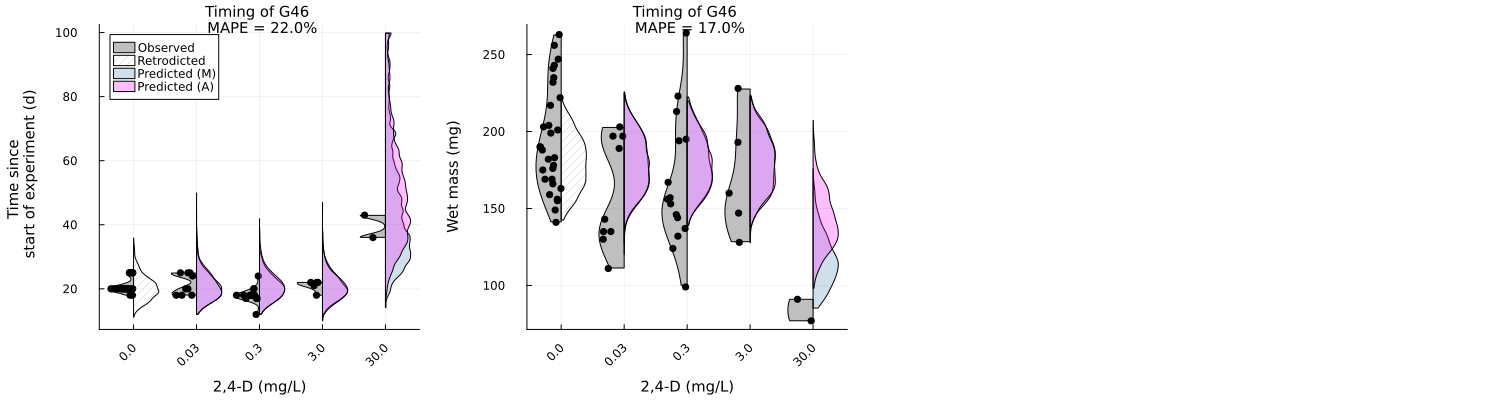

In [16]:
plt = plot_metamorphs(
    bottommargin = 10mm, leftmargin = 10mm
)

sim = EcotoxModelFitting.extract_simkey(sim_opt_M, :metamorphs)
sim_retro = @subset(sim, :treatment_id .== 1)
sim_pred = @subset(sim, :treatment_id .> 1)

@df sim_retro violin!(
    plt, subplot = 1,
    string.(:treatment_id), :t_exp_G46, 
    side = :right,
    fillalpha = .25,
    color = :gray,
    fillstyle = ://,
    label = "Retrodicted",
    title = "Timing of G46 \n MAPE = $(round(quant_eval_M.mape[1], sigdigits = 2))%"
    )

@df sim_pred violin!(
    plt, subplot = 1,
    string.(:treatment_id), :t_exp_G46, 
    side = :right,
    fillalpha = .25,
    color = :steelblue,
    label = "Predicted (M)"
    )

@df sim_retro violin!(
    plt, subplot = 2,
    string.(:treatment_id), :wetmass_G46_mg, 
    side = :right,
    fillalpha = .25,
    color = :gray,
    fillstyle = ://,
    label = "Retrodicted",
    title = "Timing of G46 \n MRE = $(round(quant_eval_M.mape[1], sigdigits = 2))%"
    )

@df sim_pred violin!(
    plt, subplot = 2,
    string.(:treatment_id), :wetmass_G46_mg, 
    side = :right,
    fillalpha = .25,
    color = :steelblue,
    label = "Predicted (M)",
    title = "Timing of G46 \n MAPE = $(round(quant_eval_M.mape[2], sigdigits = 2))%"
    )
  

sim = EcotoxModelFitting.extract_simkey(sim_opt_A, :metamorphs)
sim_retro = @subset(sim, :treatment_id .== 1)
sim_pred = @subset(sim, :treatment_id .> 1)

@df sim_pred violin!(
    plt, subplot = 1,
    string.(:treatment_id), :t_exp_G46, 
    side = :right,
    fillalpha = .25,
    color = :magenta,
    label = "Predicted (A)",
    )

@df sim_pred violin!(
    plt, subplot = 2,
    string.(:treatment_id), :wetmass_G46_mg, 
    side = :right,
    fillalpha = .25,
    color = :magenta,
    label = "Predicted (A)",
    )    

savefig(
    plot(plt, dpi = 400), 
    plotsdir("CrossValidation_Discoglossus_24D_PMoA_comparison.png")
    )

display(plt)